In [10]:
import pandas as pd
import numpy as np

def reduce_mem_usage(df):
    start_mem = df.memory_usage().sum() / 1024**2
    print(f'Initial memory: {start_mem:.2f} MB')
    
    for col in df.columns:
        col_type = df[col].dtype
        
        #testing if it is a number
        if pd.api.types.is_numeric_dtype(col_type):
            c_min = df[col].min()
            c_max = df[col].max()
            
            #if it is a integer
            if str(col_type).startswith('int'):
                if c_min > np.iinfo(np.int8).min and c_max < np.iinfo(np.int8).max:
                    df[col] = df[col].astype(np.int8)
                elif c_min > np.iinfo(np.int16).min and c_max < np.iinfo(np.int16).max:
                    df[col] = df[col].astype(np.int16)
                elif c_min > np.iinfo(np.int32).min and c_max < np.iinfo(np.int32).max:
                    df[col] = df[col].astype(np.int32)
            #if it is a float
            else:
                if c_min > np.finfo(np.float16).min and c_max < np.finfo(np.float16).max:
                    df[col] = df[col].astype(np.float16)
                elif c_min > np.finfo(np.float32).min and c_max < np.finfo(np.float32).max:
                    df[col] = df[col].astype(np.float32)
                    
        #if it's text, we convert it to 'category' to save RAM
        elif str(col_type) == 'object' or str(col_type) == 'string':
            if col != 'date':
                df[col] = df[col].astype('category')
                
    end_mem = df.memory_usage().sum() / 1024**2
    return df

In [11]:
#load
df_sales = pd.read_csv('data/sales_train_evaluation.csv')
df_calendar = pd.read_csv('data/calendar.csv')
df_prices = pd.read_csv('data/sell_prices.csv')

#transformation
id_vars = ['id', 'item_id', 'dept_id', 'cat_id', 'store_id', 'state_id']
df_ts = pd.melt(df_sales, 
                id_vars=id_vars, 
                var_name='d', 
                value_name='sales')

#downcasting
df_ts = reduce_mem_usage(df_ts)
df_calendar = reduce_mem_usage(df_calendar)
df_prices = reduce_mem_usage(df_prices)

#cross with date
cols_calendario = ['d', 'date', 'wm_yr_wk', 'event_name_1', 'snap_CA', 'snap_TX', 'snap_WI']
df_final = pd.merge(df_ts, df_calendar[cols_calendario], on='d', how='left')
df_final['date'] = pd.to_datetime(df_final['date'])

#cross with prices
df_final = pd.merge(df_final, df_prices, 
                    on=['store_id', 'item_id', 'wm_yr_wk'], 
                    how='left')

#free RAM
del df_sales, df_ts, df_calendar, df_prices
import gc
gc.collect()

df_final.info()

Initial memory: 3612.13 MB
Initial memory: 0.21 MB
Initial memory: 208.77 MB
<class 'pandas.DataFrame'>
RangeIndex: 59181090 entries, 0 to 59181089
Data columns (total 15 columns):
 #   Column        Dtype         
---  ------        -----         
 0   id            str           
 1   item_id       str           
 2   dept_id       str           
 3   cat_id        str           
 4   store_id      str           
 5   state_id      str           
 6   d             str           
 7   sales         int16         
 8   date          datetime64[us]
 9   wm_yr_wk      int16         
 10  event_name_1  str           
 11  snap_CA       int8          
 12  snap_TX       int8          
 13  snap_WI       int8          
 14  sell_price    float16       
dtypes: datetime64[us](1), float16(1), int16(2), int8(3), str(8)
memory usage: 4.5 GB


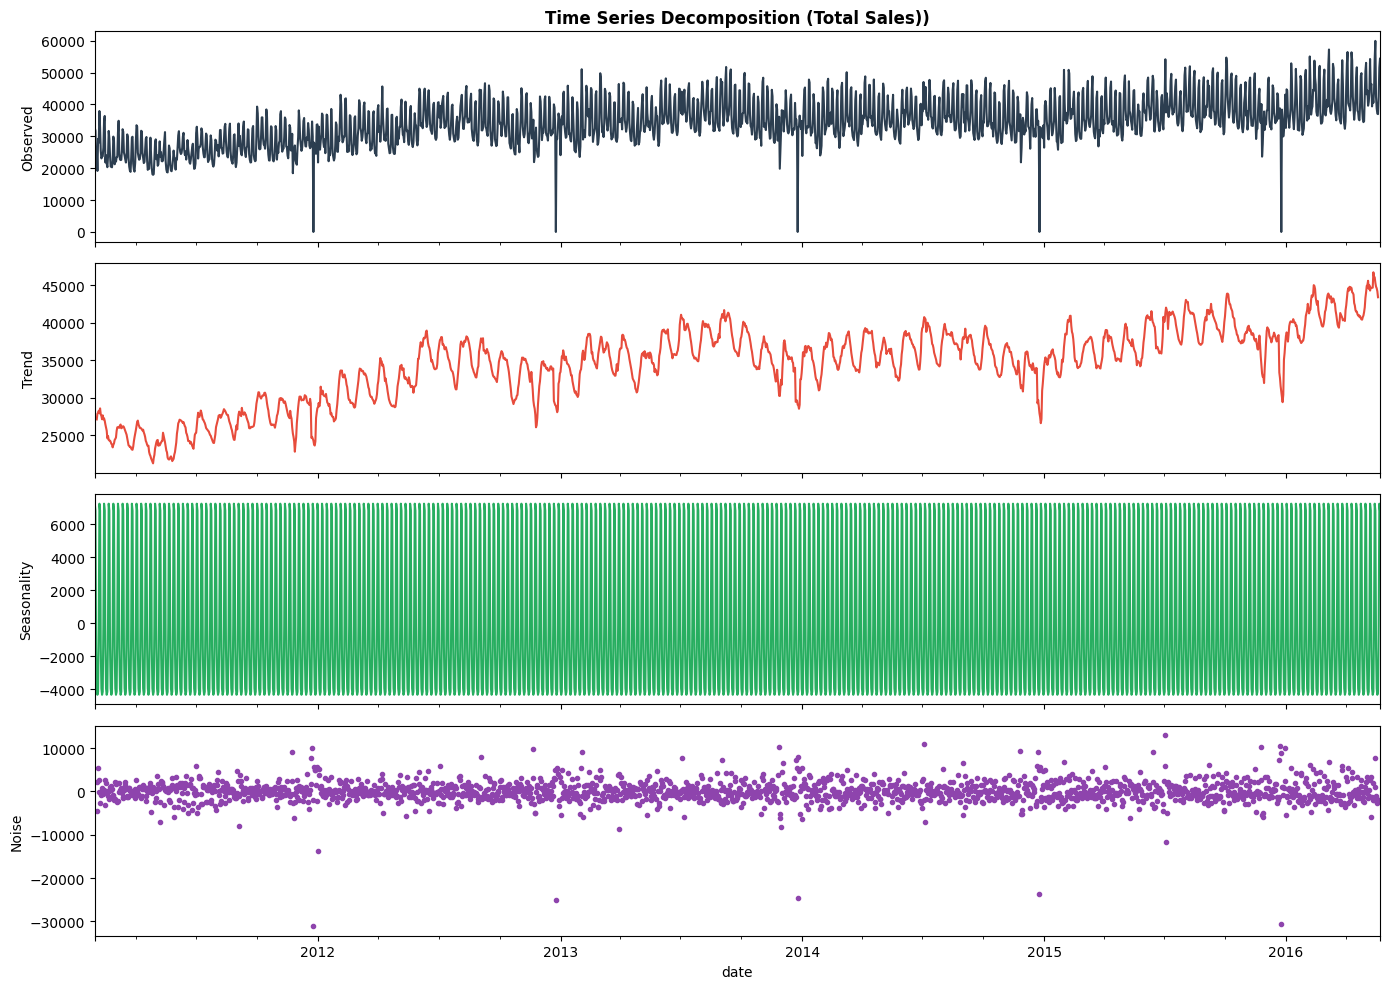

/tmp/ipykernel_51126/2439217814.py:36: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=sales_by_day.index, y=sales_by_day.values, palette="viridis")


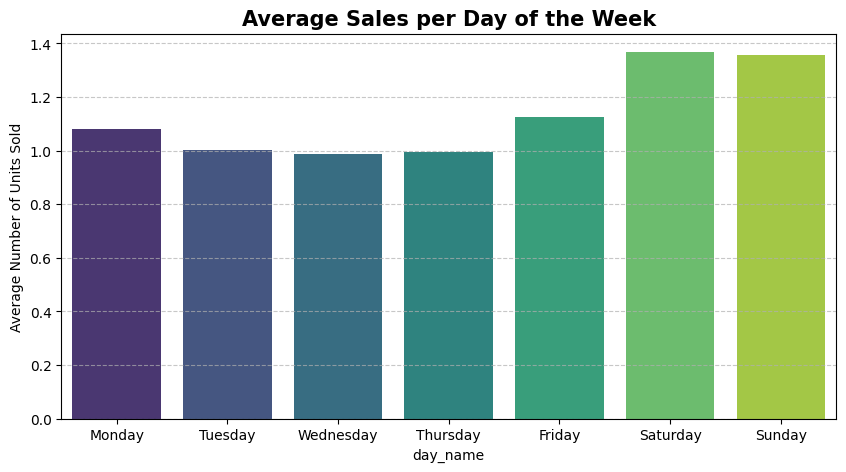

/tmp/ipykernel_51126/2439217814.py:46: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=media_snap, x='snap_CA', y='sales', palette="Set2")


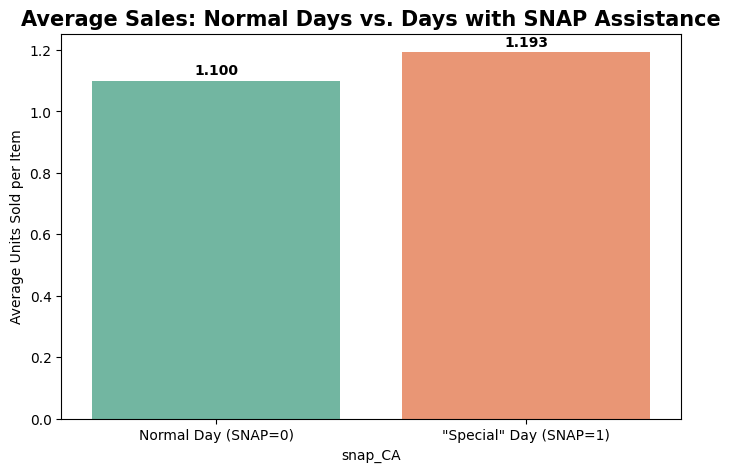

In [20]:
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.tsa.seasonal import seasonal_decompose

#right-indexed time series
ts_data = df_final.groupby('date')['sales'].sum()

#mathematical decomposition (weekly)
descomposicion = seasonal_decompose(ts_data, model='additive', period=7)

fig, axes = plt.subplots(4, 1, figsize=(14, 10), sharex=True)
descomposicion.observed.plot(ax=axes[0], color='#2c3e50')
axes[0].set_ylabel('Observed')
axes[0].set_title('Time Series Decomposition (Total Sales))', fontweight='bold')

descomposicion.trend.plot(ax=axes[1], color='#e74c3c')
axes[1].set_ylabel('Trend')

descomposicion.seasonal.plot(ax=axes[2], color='#27ae60')
axes[2].set_ylabel('Seasonality')

descomposicion.resid.plot(ax=axes[3], color='#8e44ad', style='.')
axes[3].set_ylabel('Noise')
plt.tight_layout()
plt.show()

#weekly seasonality
df_final['day_of_week'] = df_final['date'].dt.dayofweek
week_days = {0: 'Monday', 1: 'Tuesday', 2: 'Wednesday', 3: 'Thursday', 4: 'Friday', 5: 'Saturday', 6: 'Sunday'}
df_final['day_name'] = df_final['day_of_week'].map(week_days)

#average sales per day
sales_by_day = df_final.groupby('day_name')['sales'].mean().reindex(week_days.values())

plt.figure(figsize=(10, 5))
sns.barplot(x=sales_by_day.index, y=sales_by_day.values, palette="viridis")
plt.title('Average Sales per Day of the Week', fontsize=15, fontweight='bold')
plt.ylabel('Average Number of Units Sold')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

#impact of exogenous variables

media_snap = df_final.groupby('snap_CA')['sales'].mean().reset_index()
plt.figure(figsize=(8, 5))
sns.barplot(data=media_snap, x='snap_CA', y='sales', palette="Set2")

plt.title('Average Sales: Normal Days vs. Days with SNAP Assistance', fontsize=15, fontweight='bold')
plt.xticks([0, 1], ['Normal Day (SNAP=0)', '"Special" Day (SNAP=1)'])
plt.ylabel('Average Units Sold per Item')
for index, row in media_snap.iterrows():
    plt.text(index, row.sales + 0.02, f'{row.sales:.3f}', color='black', ha="center", fontweight='bold')

plt.show()

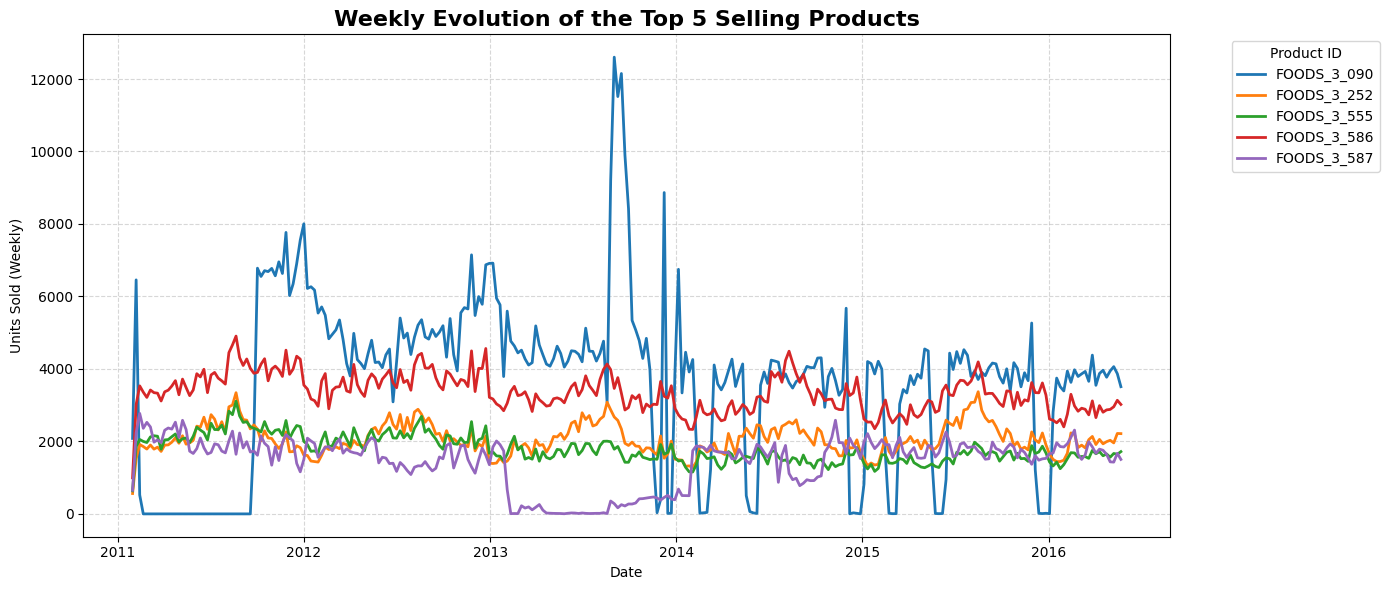

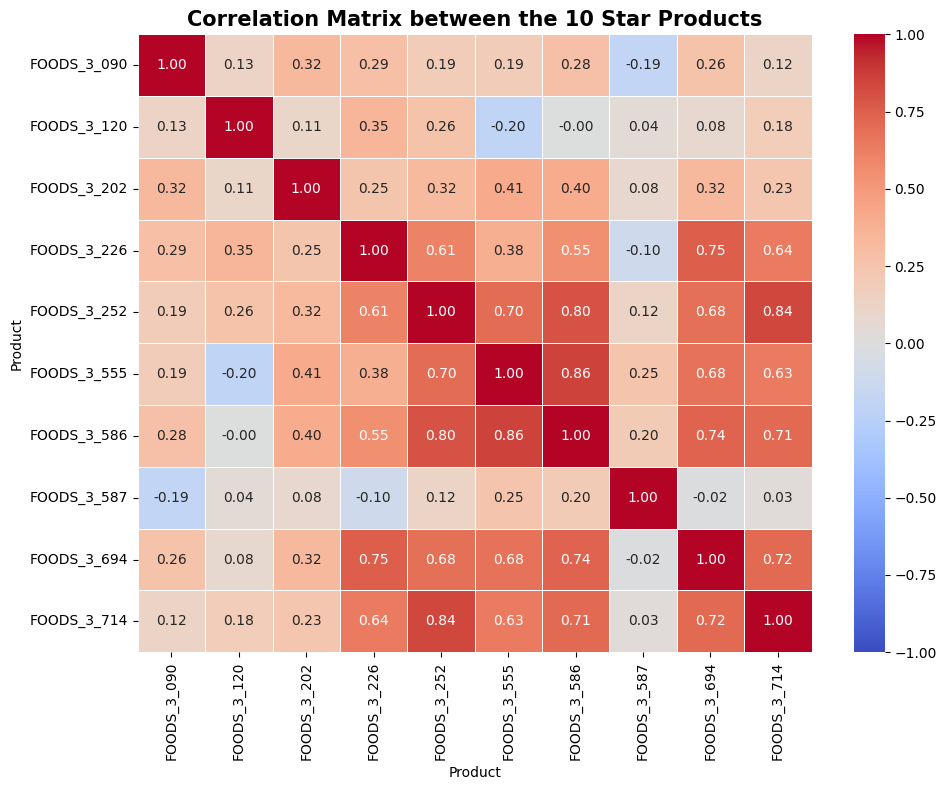

In [13]:
#analysis of star products
top_10_ids = df_final.groupby('item_id')['sales'].sum().nlargest(10).index.tolist()

#we filter
df_top10 = df_final[df_final['item_id'].isin(top_10_ids)]

#graph 1: individual temporal evolution
top_5_ids = top_10_ids[:5]
df_top5 = df_top10[df_top10['item_id'].isin(top_5_ids)]

#grouped weekly
df_top5_weekly = df_top5.groupby(['item_id', pd.Grouper(key='date', freq='W')])['sales'].sum().reset_index()

plt.figure(figsize=(14, 6))
sns.lineplot(data=df_top5_weekly, x='date', y='sales', hue='item_id', palette='tab10', linewidth=2)
plt.title('Weekly Evolution of the Top 5 Selling Products', fontsize=16, fontweight='bold')
plt.xlabel('Date')
plt.ylabel('Units Sold (Weekly)')
plt.legend(title='Product ID', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()


#graph 2: correlation matrix
df_pivot = df_top10.pivot_table(index='date', columns='item_id', values='sales', aggfunc='sum')
matriz_correlation = df_pivot.corr()

plt.figure(figsize=(10, 8))
sns.heatmap(matriz_correlation, annot=True, cmap='coolwarm', fmt=".2f", linewidths=.5, vmin=-1, vmax=1)
plt.title('Correlation Matrix between the 10 Star Products', fontsize=15, fontweight='bold')
plt.xlabel('Product')
plt.ylabel('Product')
plt.tight_layout()
plt.show()

ADF Statistician: -1.2961
P-valor: 0.6310
Conclusion: The series IS NOT STATIONARY (It needs 'I' differentiation in ARIMA).


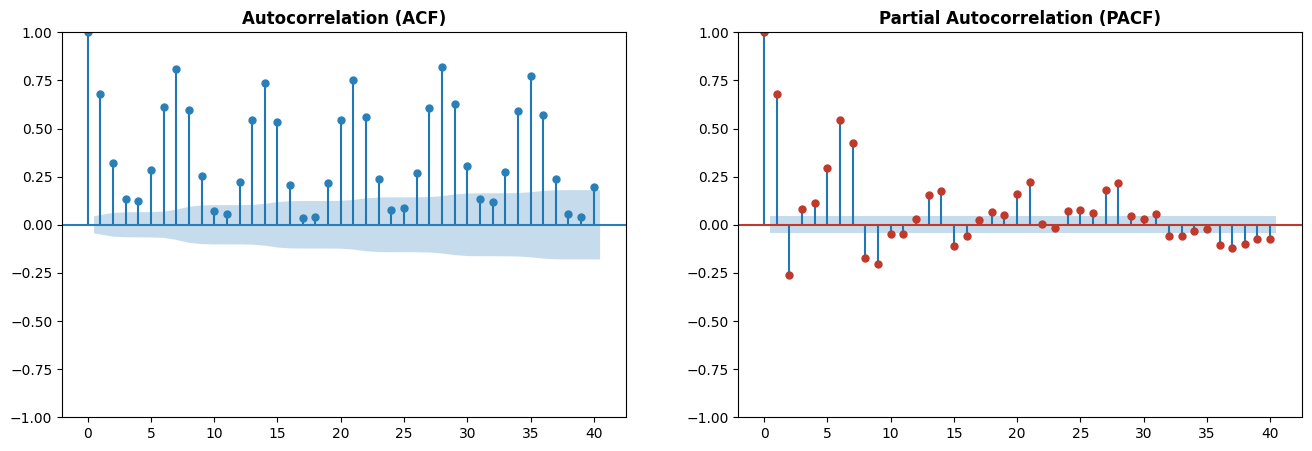

In [17]:
from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

#We used aggregate sales for this statistical test
ts_data = df_final.groupby('date')['sales'].sum()

#Dickey-Fuller Aumentet Test
resultado_adf = adfuller(ts_data.dropna())
print(f'ADF Statistician: {resultado_adf[0]:.4f}')
print(f'P-valor: {resultado_adf[1]:.4f}')
if resultado_adf[1] < 0.05:
    print("Conclusion: The series is STATIONARY (We reject the null hypothesis).")
else:
    print("Conclusion: The series IS NOT STATIONARY (It needs 'I' differentiation in ARIMA).")

#Autocorrelation Graphs (ACF y PACF)
fig, axes = plt.subplots(1, 2, figsize=(16, 5))
plot_acf(ts_data.dropna(), lags=40, ax=axes[0], color='#2980b9')
axes[0].set_title('Autocorrelation (ACF)', fontweight='bold')

plot_pacf(ts_data.dropna(), lags=40, ax=axes[1], color='#c0392b')
axes[1].set_title('Partial Autocorrelation (PACF)', fontweight='bold')
plt.show()

In [18]:

#we are keeping only the 10 star products that we're going to predict
df_models = df_top10.copy()
df_models['day_num'] = df_models['d'].str.replace('d_', '').astype(int)

#we make the strict chronological division for Deep Learning / SARIMAX
train = df_models[df_models['day_num'] <= 1885]
val   = df_models[(df_models['day_num'] > 1885) & (df_models['day_num'] <= 1913)]
test  = df_models[df_models['day_num'] > 1913]

print(f"Training Set Size (Days 1-1885): {len(train):,} rows")
print(f"Validation Set Size  (Days 1886-1913): {len(val):,} rows")
print(f"Testing Set Size (Days 1914-1941): {len(test):,} rows")


Training Set Size (Days 1-1885): 188,500 rows
Validation Set Size  (Days 1886-1913): 2,800 rows
Testing Set Size (Days 1914-1941): 2,800 rows
